# <center>Impact of the COVID-19 Pandemic on Unemployment Rates for Students and Non-Students in Ten Canadian Provinces and Counterfactual Predictions</center>
### <center>Wenliang Wang</center>

# 0. Econometric Model 

$$Y_{it} = \mu_i + \lambda_t + \beta_1 treated_i + \beta_2 post_t + \beta_3 DID_{it} + \varepsilon_{it}\tag{1}$$

####  This is the difference-in-difference model with two-way fixed effect that would be used for the analysis. 

$\displaystyle Y_{it}$ ： Dependent variable (or called target variable)

$\mu_i$ :  The individual fixed effect, that controls the effects created by each individual's heterogeneity at all timepoints.

$\lambda_t$ :  The time fixed effect，that controls the effects created by each timepoint's effect on all individuals.

$\displaystyle treated_i$ :  The dummy variable of treated group. 

$\displaystyle post_t$:    The dummy variable of the time after 2020-03 

$\displaystyle DID_{it}$ :  Interaction variable as $\displaystyle treated_i$ *$\displaystyle post_t$

$\epsilon_{it}$:   Idiosyncratic error term

# 1. Interaction between Python and Stata

In [1]:
#Read the stata dataset.
import pandas as pd
data = pd.read_stata('Documents/加拿大数据/疫情对学生失业率的冲击/划分处理组/dta/full-time students.dta')

#Connect python with my local stata.
import os
os.chdir(r'C:\Program FIles\Stata18\utilities')
from pystata import config
config.init('mp')

#Transport the dataset "data" to stata environment.
from pystata import stata
stata.pdataframe_to_data(data, force=True)


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-STATA-PC        https://www.stata.com
                                   979-696-4600        stata@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806366047
  Licensed to: LL
               JZ

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [2]:
#Set up the dataset as a panel data
stata.run("""encode geo, gen(province_id_new)
encode ref_date, gen(date_new)
drop province_id
drop date
rename province_id_new province_id
rename date_new date
xtset province_id date""")


. encode geo, gen(province_id_new)

. encode ref_date, gen(date_new)

. drop province_id

. drop date

. rename province_id_new province_id

. rename date_new date

. xtset province_id date

Panel variable: province_id (strongly balanced)
 Time variable: date, 1 to 88
         Delta: 1 unit

. 


# 2. Start Regression Running in Stata Environment

* I only put the most critical regression tables here showing the DID model results straightly, for more detailed regression results and commands, please check the do files and log. 

## (1). Full-time Students as the Target Population for Analysis

### a. Let Ontario and Quebec be as the treated group, while Four Atlantic Provinces as the control group

In [3]:
# Let "unemployment rate" be the dependent variable.
stata.run("""xtscc unemploymentrate  did  year_*  month_*  if compare_sample !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =     12.84
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1919

------------------------------------------------------------------------------
             |             Drisc/Kraay
unemployme~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |   1.510969   1.234209     1.22   0.224    -.9421555    3.964093
      year_1 |   .1119897   .6178738     0.18   0.857    -1.116101    1.340081
      year_2 |  -.1942602   .5427862    -0.36   0.721    -1.273107    .8845862
      year_3 |  -.0713437   .7802512    -0.09   0.927    -1.622177     1.47949
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 1
</div>

In [4]:
# Let "participation rate" be the dependent variable.
stata.run("""xtscc participationrate  did  year_*  month_*  if compare_sample !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =     17.17
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1373

------------------------------------------------------------------------------
             |             Drisc/Kraay
participat~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |   1.603364   .8261976     1.94   0.056    -.0387936    3.245521
      year_1 |   3.394871   .3595866     9.44   0.000     2.680154    4.109589
      year_2 |   3.076121   .5349625     5.75   0.000     2.012825    4.139417
      year_3 |   3.611538   .6109565     5.91   0.000     2.397196     4.82588
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 2
</div>

In [5]:
# Let "nowork" be the dependent variable.
stata.run("""xtscc nowork  did  year_*  month_*  if compare_sample !=., fe lag(3)
""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =     20.09
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1532

------------------------------------------------------------------------------
             |             Drisc/Kraay
      nowork | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |  -.8267319   1.121868    -0.74   0.463    -3.056566    1.403103
      year_1 |  -2.871411   .4178691    -6.87   0.000    -3.701971   -2.040851
      year_2 |  -2.746411   .6200109    -4.43   0.000     -3.97875   -1.514072
      year_3 |   -3.15891   .8371002    -3.77   0.000    -4.822738   -1.495083
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 3
</div>

### b. Let Alberta, Saskatchewan, Manitoba and British Columbia be the treated group

In [6]:
# Let "unemployment rate" be the dependent variable.
stata.run("""xtscc unemploymentrate  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =     20.12
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.2538

------------------------------------------------------------------------------
             |             Drisc/Kraay
unemployme~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |   2.593202   1.115569     2.32   0.022     .3758874    4.810516
      year_1 |  -.3656249   .7908509    -0.46   0.645    -1.937527    1.206277
      year_2 |   .3484376   .7863103     0.44   0.659    -1.214439    1.911314
      year_3 |    .521875   .8930839     0.58   0.560    -1.253226    2.296976
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 4
</div>


In [7]:
# Let "participation rate" be the dependent variable.
stata.run("""xtscc participationrate  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =      6.81
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1586

------------------------------------------------------------------------------
             |             Drisc/Kraay
participat~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |  -.0004628   .7280876    -0.00   0.999    -1.447616     1.44669
      year_1 |   2.38e-07   .3681127     0.00   1.000    -.7316637    .7316641
      year_2 |   .2953127   .5263911     0.56   0.576    -.7509466    1.341572
      year_3 |   .7390626   .5088824     1.45   0.150    -.2723962    1.750521
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 5
</div>

In [8]:
# Let "nowork" be the dependent variable.
stata.run("""xtscc nowork  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)
""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =     11.91
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1996

------------------------------------------------------------------------------
             |             Drisc/Kraay
      nowork | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |   1.054337   .9807987     1.07   0.285    -.8951065    3.003781
      year_1 |   -.115625    .396689    -0.29   0.771    -.9040873    .6728373
      year_2 |      -.075   .5625298    -0.13   0.894    -1.193089    1.043089
      year_3 |  -.3984372   .6449411    -0.62   0.538    -1.680327     .883453
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 6
</div>

### *Create interaction again between Python and Stata for non-students group
* Before starting this part, I restart kernel so that notebook can read the new dta file successfully, or there will be error reported.

In [1]:
import pandas as pd
data2 = pd.read_stata('Documents/加拿大数据/疫情对学生失业率的冲击/划分处理组/dta/non-students.dta') 
import os
os.chdir(r'C:\Program FIles\Stata18\utilities')
from pystata import config
config.init('mp')
from pystata import stata
stata.pdataframe_to_data(data2, force=True)


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-STATA-PC        https://www.stata.com
                                   979-696-4600        stata@stata.com

Stata license: Single-user 2-core  perpetual
Serial number: 501806366047
  Licensed to: LL
               JZ

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


In [2]:
#Set up the dataset as a panel data
stata.run("""encode geo, gen(province_id_new)
encode ref_date, gen(date_new)
drop province_id
drop date
rename province_id_new province_id
rename date_new date
xtset province_id date""")


. encode geo, gen(province_id_new)

. encode ref_date, gen(date_new)

. drop province_id

. drop date

. rename province_id_new province_id

. rename date_new date

. xtset province_id date

Panel variable: province_id (strongly balanced)
 Time variable: date, 1 to 88
         Delta: 1 unit

. 


## (2). Non-students as the Target Population for Analysis

### a. Let Ontario and Quebec be the treated group, while Four Atlantic Provinces be the control group

In [3]:
# Let "unemployment rate" be the dependent variable.
stata.run("""xtscc unemploymentrate  did  year_*  month_*  if compare_sample !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =     17.53
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.3770

------------------------------------------------------------------------------
             |             Drisc/Kraay
unemployme~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |   3.689132   .8631609     4.27   0.000     1.973506    5.404757
      year_1 |   4.494294   1.024839     4.39   0.000     2.457315    6.531272
      year_2 |    3.61721    .632869     5.72   0.000     2.359315    4.875106
      year_3 |   2.796377   1.091879     2.56   0.012     .6261489    4.966605
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 7
</div>

In [4]:
# Let "participation rate" be the dependent variable.
stata.run("""xtscc participationrate  did  year_*  month_*  if compare_sample !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =      5.38
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1781

------------------------------------------------------------------------------
             |             Drisc/Kraay
participat~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |  -.5698797   .7603124    -0.75   0.456    -2.081083    .9413236
      year_1 |   -.079543    .625486    -0.13   0.899    -1.322764    1.163678
      year_2 |  -.9024597   .4571662    -1.97   0.052    -1.811127    .0062077
      year_3 |  -1.798293   .5616062    -3.20   0.002    -2.914546   -.6820401
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 8
</div>

In [5]:
# Let "nowork" be the dependent variable.
stata.run("""xtscc nowork  did  year_*  month_*  if compare_sample !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       528
Method: Fixed-effects regression                 Number of groups  =         6
Group variable (i): province_id                  F( 18,    87)     =     16.10
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.3604

------------------------------------------------------------------------------
             |             Drisc/Kraay
      nowork | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         did |   3.670708   1.154412     3.18   0.002     1.376189    5.965227
      year_1 |   4.090236   .6322646     6.47   0.000     2.833542    5.346931
      year_2 |   4.044402    .528171     7.66   0.000     2.994605    5.094199
      year_3 |    3.89857   1.188217     3.28   0.001     1.536861    6.260279
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 9
</div>

### b. Let Alberta, Saskatchewan, Manitoba and British Columbia be the treated group

In [6]:
# Let "unemployment rate" be the dependent variable.
stata.run("""xtscc unemploymentrate  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =     13.72
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.3326

------------------------------------------------------------------------------
             |             Drisc/Kraay
unemployme~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |   3.960136    .844363     4.69   0.000     2.281874    5.638399
      year_1 |     2.3625   .4972948     4.75   0.000     1.374073    3.350927
      year_2 |   2.276562   .3190202     7.14   0.000     1.642475     2.91065
      year_3 |   2.034375   .7687957     2.65   0.010     .5063103     3.56244
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 10
</div>

In [7]:
# Let "participation rate" be the dependent variable.
stata.run("""xtscc participationrate  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =      6.85
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.1822

------------------------------------------------------------------------------
             |             Drisc/Kraay
participat~e | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |  -1.578996   .7283824    -2.17   0.033    -3.026735    -.131257
      year_1 |   .1968752   .3123462     0.63   0.530    -.4239466     .817697
      year_2 |  -.7390627    .252706    -2.92   0.004    -1.241343   -.2367822
      year_3 |  -1.539063   .2513227    -6.12   0.000    -2.038594   -1.039531
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 11
</div>

In [8]:
# Let "nowork" be the dependent variable.
stata.run("""xtscc nowork  did2  year_*  month_*  if compare_sample2 !=., fe lag(3)""")


Regression with Driscoll-Kraay standard errors   Number of obs     =       704
Method: Fixed-effects regression                 Number of groups  =         8
Group variable (i): province_id                  F( 18,    87)     =     12.10
maximum lag: 3                                   Prob > F          =    0.0000
                                                 within R-squared  =    0.3461

------------------------------------------------------------------------------
             |             Drisc/Kraay
      nowork | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        did2 |   4.812403   1.012599     4.75   0.000     2.799753    6.825053
      year_1 |   1.896876   .3598401     5.27   0.000     1.181654    2.612097
      year_2 |    2.64375    .429305     6.16   0.000      1.79046     3.49704
      year_3 |   2.978126    .816429     3.65   0.000     1.355385    4.600867
      year_

<div style="font-size: 20px; margin-left: 25%;">
    Table 12
</div>

# 3. DID Coefficients Visualization (Histograms of shocks to unemployment and nowork rate)

In [9]:
import matplotlib.pyplot as plt

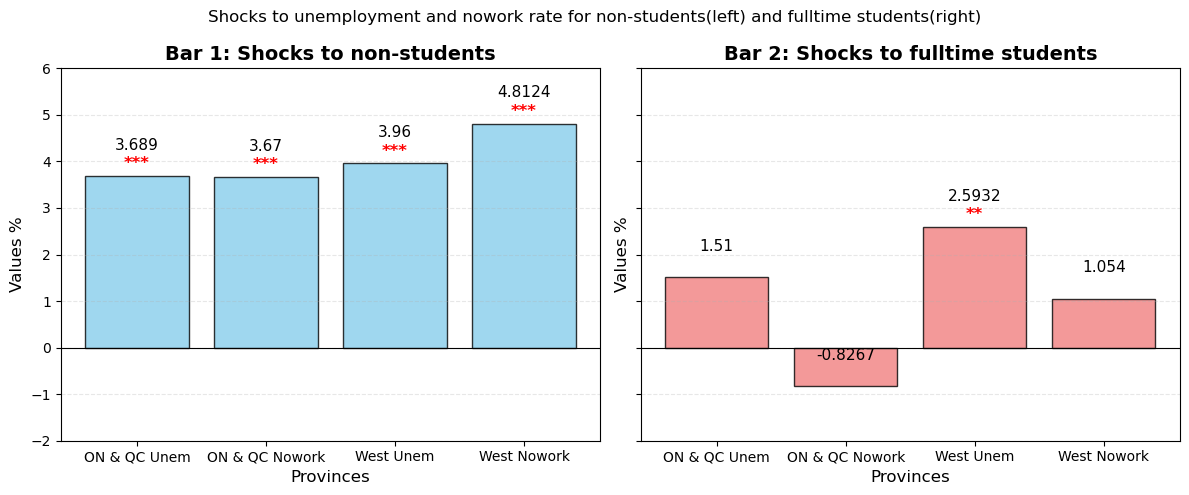

In [10]:
provinces_1 = ['ON & QC Unem','ON & QC Nowork', 'West Unem','West Nowork']
provinces_2 = ['ON & QC Unem','ON & QC Nowork', 'West Unem','West Nowork']
coefficients_1 = [3.689, 3.67, 3.96, 4.8124]
coefficients_2 = [1.51,-0.8267, 2.5932,1.054]
#Build two histograms side by side。
fig,axes = plt.subplots(1,2, figsize=(12,5),sharey=True)

#Buid the bar gragh of non-students on left.
bar_left = axes[0].bar(provinces_1, coefficients_1, color='skyblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Bar 1: Shocks to non-students', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Provinces', fontsize=12)
axes[0].set_ylabel('Values %', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i,v in enumerate(coefficients_1):
    axes[0].text(i,v+0.5, str(v), ha='center',va='bottom', fontsize=11)

#Built the bar gragh of fulltime students on right.
bar_right = axes[1].bar(provinces_2, coefficients_2,color='lightcoral', alpha=0.8, edgecolor='black')
axes[1].set_title('Bar 2: Shocks to fulltime students', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Provinces', fontsize=12)
axes[1].set_ylabel('Values %', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i,v in enumerate(coefficients_2):
    axes[1].text(i,v+0.5, str(v), ha='center',va='bottom', fontsize=11)

#Label statistical significance.
nonstudents_sig = ['***', '***', '***', '***']
fulltime_sig = ['', '', '**', '']
for i, ax in enumerate(axes):
    ax.set_ylim(-2, 6)  # Use same y-axist scale
    ax.axhline(0, color='black', linewidth=0.8) # Make each box have black boundary.
    ax.grid(axis='y', linestyle='--', alpha=0.3) 
    
# Automatic label
    current_bars = bar_left if i == 0 else bar_right
    current_sig = nonstudents_sig if i == 0 else fulltime_sig
    
    for bar, sig in zip(current_bars, current_sig):
        height = bar.get_height()
        # 0.1 unit over each bar.
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                sig, ha='center', va='bottom', color='red', fontsize=12, fontweight='bold')


fig.suptitle('Shocks to unemployment and nowork rate for non-students(left) and fulltime students(right)')
plt.tight_layout()
plt.show()

* Causal Identification: Using the four Atlantic provinces as a baseline control group, the DID model clearly captures the excess employment shock of lockdown policies in other regions. 

*  Regional Differences in Non-Student Groups:  The four western provinces showed the most severe response, with an unemployment rate $3.96\%$ higher and a nowork rate (rate of exit labor market) $4.81\%$ higher than the four Atlantic provinces ($p<0.01$). Ontario and Quebec followed, with a less higher unemployment rate of $3.689\%$ and nowork rate of $3.67\%$  ($p<0.01$) than the four Atlantic provinces.

* Placebo Test (Identity Hedging):  Compared to non-student groups, full-time students in Ontario and Quebec showed **NO** statistically significant difference from those in the four Atlantic provinces (coefficient not significant). This demonstrates that the macroeconomic shock did not affect all groups, and the rise in unemployment is a policy consequence precisely present in the non-student labor market. 

* Conclusion: The bar chart visually illustrates the "shock gradient" with the Atlantic region as the zero point, confirming the extreme vulnerability of the western labor market under policy intervention.

# 4. Causal Evidence: Deconstructing the Policy Impact

The section above employs a difference-in-differences (DID) model to deeply analyze the causal impact of lockdown policies on youth employment. Using the four Atlantic provinces as a benchmark, the results reveal significant "identity stratification" and "regional asymmetry" in the labor market under pandemic shocks.

 On the identity dimension, the policies exhibit precise targeting: non-student youth already in the workforce bear the brunt of the employment pains, with their unemployment and shutdown indices surging dramatically nationwide. In contrast, full-time students in Ontario and Quebec demonstrate remarkable resilience, with **NO** statistically significant differences in their indicators compared to the benchmark group. This comparison constitutes a robust "placebo test," eliminating the interference of a systemic macroeconomic collapse in the early stages of the pandemic and confirming that the core cause of the employment crisis lies in policy restrictions targeting specific labor markets.

On the regional dimension, the shock exhibits a clear "west-east gradient": the four western provinces show the most vulnerable response characteristics, generating not only the highest unemployment premium among non-student groups but also leading to a significant unemployment premium even among students who were previously in academia. This cross-group linkage effect reflects the high dependence of resource-dependent industries in the west on offline physical contact, resulting in a stronger spillover and resonance of policy shocks in the west.

In conclusion, the strong contrast presented in the bar chart completes both qualitative and quantitative verification of the causality of policy shocks.

# 5. Reproduction of Stata Estimates in Python

* To ensure the reliability of the Stata estimates shown in tables above, I implement a Numpy-based reproduction of the these estimates using Python. This cross-validation step serves to confirm that the underlying matrix operations and data structures are consistent across platforms, providing a solid, verified baseline for the subsequent machine learning predictive analysis.

The estimates reproduction is based on the calculation of Fixed Effect estimator or named "within-group estimator". We already build the model equation at the beginning as : $$Y_{it} = \mu_i + \lambda_t + \beta_1 treated_i + \beta_2 post_t + \beta_3 DID_{it} + \varepsilon_{it}\tag{1}$$
Firstly, transform it by individual mean-defferencing, we can get: $$Y_{it} - \overline{Y}_i = (\mu_i-\mu_i) + \lambda_t + \beta_1(treated_i-treated_i) + \beta_2 post_t + \beta_3(DID_{it}-\overline{DID}_i) + (\varepsilon_{it}- \bar{\varepsilon}_i)\tag{2} $$  
$$Y_{it} - \overline{Y}_i = \lambda_t + \beta_2 post_t + \beta_3(DID_{it}-\overline{DID}_i) + (\varepsilon_{it}- \bar{\varepsilon}_i)\tag{3} $$  
Next, transform it by time mean-difference, we can get: $$Y_{it} - \overline{Y}_i = \beta_3( DID_{it}-\overline{DID}_i) + (\varepsilon_{it}- \bar{\varepsilon}_i)\tag{4} $$  
Finally, we get a new equation: $$\widetilde{Y}_{it} = \beta(\widetilde{DID}_{it}) + \tilde\varepsilon_{it}\tag{5} $$ 
Where we define $\widetilde{Y}_{it} = Y_{it} - \overline{Y}_i$，$\beta(\widetilde{DID}_{it}) = \beta_3( DID_{it}-\overline{DID}_i)$ and $\tilde\varepsilon_{it} = \varepsilon_{it}- \bar{\varepsilon}_i$

The equation $(5)$ would be the theoretical basis for reproducing coffecient estimates by Numpy below. In the empirical case here, there are two variables "year" and "month" standing for time, so I must kick out both "year_mean" and "month_mean" to control the time fixed effect.

## (1). Reproduction from table 1 to table 6

In [5]:
import pandas as pd
import numpy as np
panel_1 = pd.read_csv('Documents/加拿大数据/疫情对学生失业率的冲击/划分处理组/dta/fulltime.csv')
keep_provinces = ["Ontario", "Quebec", "Nova Scotia", "New Brunswick", "Prince Edward Island", "Newfoundland and Labrador"]
data_1 = panel_1[panel_1['province_id'].isin(keep_provinces)].copy()

# def the function of two-way fixed effect
def twfe(data, entity, year, month):
    entity_mean = data.groupby(entity).transform('mean')
    data_dmean = data - entity_mean
    year_mean = data_dmean.groupby(year).transform('mean')
    month_mean = data_dmean.groupby(month).transform('mean')
    return data_dmean - year_mean - month_mean
    
Y1_1 = twfe(data_1['unemploymentrate'], data_1['province_id'], data_1['year'], data_1['month'])
Y1_2 = twfe(data_1['participationrate'], data_1['province_id'], data_1['year'], data_1['month'])
Y1_3 = twfe(data_1['nowork'], data_1['province_id'], data_1['year'], data_1['month'])
did1_1 = twfe(data_1['did'], data_1['province_id'], data_1['year'], data_1['month']).to_numpy()

beta1_1 = np.sum(did1_1 * Y1_1) / np.sum(did1_1**2)
beta1_2 = np.sum(did1_1 * Y1_2) / np.sum(did1_1**2)
beta1_3 = np.sum(did1_1 * Y1_3) / np.sum(did1_1**2)


data_2 = panel_1[~panel_1['province_id'].isin(['Ontario', 'Quebec'])]
newY1_1 = twfe(data_2['unemploymentrate'], data_2['province_id'], data_2['year'], data_2['month'])
newY1_2 = twfe(data_2['participationrate'], data_2['province_id'], data_2['year'], data_2['month'])
newY1_3 = twfe(data_2['nowork'], data_2['province_id'], data_2['year'], data_2['month'])
did1_2 = twfe(data_2['did2'], data_2['province_id'], data_2['year'], data_2['month']).to_numpy()

newbeta1_1 = np.sum(did1_2 * newY1_1) / np.sum(did1_2**2)
newbeta1_2 = np.sum(did1_2 * newY1_2) / np.sum(did1_2**2)
newbeta1_3 = np.sum(did1_2 * newY1_3) / np.sum(did1_2**2)

print("The estimates shown in stata table 1 to table 6 reproduced by Numpy as: [%4.5f,  %4.5f, %4.5f, %4.5f, %4.5f, %4.5f]." % 
      (beta1_1, beta1_2, beta1_3, newbeta1_1, newbeta1_2, newbeta1_3), "The numpy results are almost same as the stata estimates !!!")

The estimates shown in stata table 1 to table 6 reproduced by Numpy as: [1.51097,  1.60336, -0.82673, 2.59320, -0.00046, 1.05434]. The numpy results are almost same as the stata estimates !!!


* The estimates shown in stata table 1 to table 6 reproduced by Numpy as: [1.51097,  1.60336, -0.82673, 2.59320, -0.00046, 1.05434]. The numpy results are consistent with the stata estimates.

## (2). Reproduction from table 7 to table 12

In [7]:
panel_2 = pd.read_csv('Documents/加拿大数据/疫情对学生失业率的冲击/划分处理组/dta/nonstudents.csv')
data_3 = panel_2[~panel_2['province_id'].isin(['Alberta', 'Manitoba', 'Saskatchewan', 'British Columbia'])]

Y2_1 = twfe(data_3['unemploymentrate'], data_3['province_id'], data_3['year'], data_3['month'])
Y2_2 = twfe(data_3['participationrate'], data_3['province_id'], data_3['year'], data_3['month'])
Y2_3 = twfe(data_3['nowork'], data_3['province_id'], data_3['year'], data_3['month'])
did2_1 = twfe(data_3['did'], data_3['province_id'], data_3['year'], data_3['month']).to_numpy()

beta2_1 = np.sum(did2_1 * Y2_1) / np.sum(did2_1**2)
beta2_2 = np.sum(did2_1 * Y2_2) / np.sum(did2_1**2)
beta2_3 = np.sum(did2_1 * Y2_3) / np.sum(did2_1**2)

data_4 = panel_2[~panel_2['province_id'].isin(['Ontario', 'Quebec'])]
newY2_1 = twfe(data_4['unemploymentrate'], data_4['province_id'], data_4['year'], data_4['month'])
newY2_2 = twfe(data_4['participationrate'], data_4['province_id'], data_4['year'], data_4['month'])
newY2_3 = twfe(data_4['nowork'], data_4['province_id'], data_4['year'], data_4['month'])
did2_2 = twfe(data_4['did2'], data_4['province_id'], data_4['year'], data_4['month']).to_numpy()

newbeta2_1 = np.sum(did2_2 * newY2_1) / np.sum(did2_2**2)
newbeta2_2 = np.sum(did2_2 * newY2_2) / np.sum(did2_2**2)
newbeta2_3 = np.sum(did2_2 * newY2_3) / np.sum(did2_2**2)

print("The estimates shown in stata table 7 to table 12 reproduced by Numpy as: [%4.5f,  %4.5f, %4.5f, %4.5f, %4.5f, %4.5f]." % 
      (beta2_1, beta2_2, beta2_3, newbeta2_1, newbeta2_2, newbeta2_3), "The numpy results are almost same as the stata estimates !!!")

The estimates shown in stata table 7 to table 12 reproduced by Numpy as: [3.68913,  -0.56988, 3.67071, 3.96014, -1.57900, 4.81240]. The numpy results are almost same as the stata estimates !!!


* The estimates shown in stata table 7 to table 12 reproduced by Numpy as: [3.68913,  -0.56988, 3.67071, 3.96014, -1.57900, 4.81240]. The numpy results are consistent with the stata estimates.

Overall, the NumPy-based reproduction confirms that the Python implementation yields results numerically identical to the Stata estimates presented in Tables 1-12. This cross-platform consistency validates the integrity of the data preprocessing and provides a rigorous foundation for the subsequent machine learning analysis."

# 6. Counterfactual Simulation by Machine Learning

In [2]:
!pip install xgboost
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

## (1). Counterfactual predictions after COVID-19 starts

In [3]:
data = pd.read_csv('Documents/加拿大数据/疫情对学生失业率的冲击/project包/data/full_non.csv')
prov_features = ['province_id']
time_features = [col for col in data.columns if 'year_' in col or 'month_' in col]
total_features = prov_features + time_features

train_data = data[(data['year'] < 2020) | ((data['year'] == 2020) & (data['month'] < 3))]
test_data = data[(data['year'] > 2020) | ((data['year'] == 2020) & (data['month'] >= 3))]

X_train = train_data[total_features].copy()
y_train = train_data['unemploymentrate']
X_test = test_data[total_features].copy()
y_test = test_data['unemploymentrate']

X_train['province_id'] = X_train['province_id'].astype('category')
X_test['province_id'] = X_test['province_id'].astype('category')

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    enable_categorical=True,
    random_state=42)
model.fit(X_train, y_train)

print("The R² showing how well the predicted result fits test set is %4.5f" % (model.score(X_test, y_test)))

The R² showing how well the predicted result fits test set is -0.02652


### Use Placebo Test to "Predict" the Data of Target Variable in 2018 

In [4]:
train_placebo = data[data['year'] < 2018]
test_placebo = data[data['year'] == 2018]
X_train_p = train_placebo[total_features].copy()
y_train_p = train_placebo['unemploymentrate']
X_test_p = test_placebo[total_features].copy()
y_test_p = test_placebo['unemploymentrate']


X_train_p['province_id'] = X_train_p['province_id'].astype('category')
X_test_p['province_id'] = X_test_p['province_id'].astype('category')

model_placebo = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    enable_categorical=True,
    random_state=42)
model_placebo.fit(X_train_p, y_train_p)

score_normal = model_placebo.score(X_test_p, y_test_p)
print("The R² showing how well the predicted result fits test set is %4.5f" % (score_normal))

The R² showing how well the predicted result fits test set is 0.46042


* To verify the model's effectiveness, a placebo test was conducted. The results show that the model demonstrated strong explanatory power when predicting 2018 (a normal year) ($R^2 = 0.46$). However, when applying the same logic to predict the impactful period of 2020, $R^2$ plummeted to a negative value ($-0.03$). This result significantly confirms that the fluctuations in the 2020 labor market were not a continuation of the normal economic cycle, but rather a structural deviation caused by sudden external shocks.

## (2). Visualization

### a. Key Predictors and Correlation

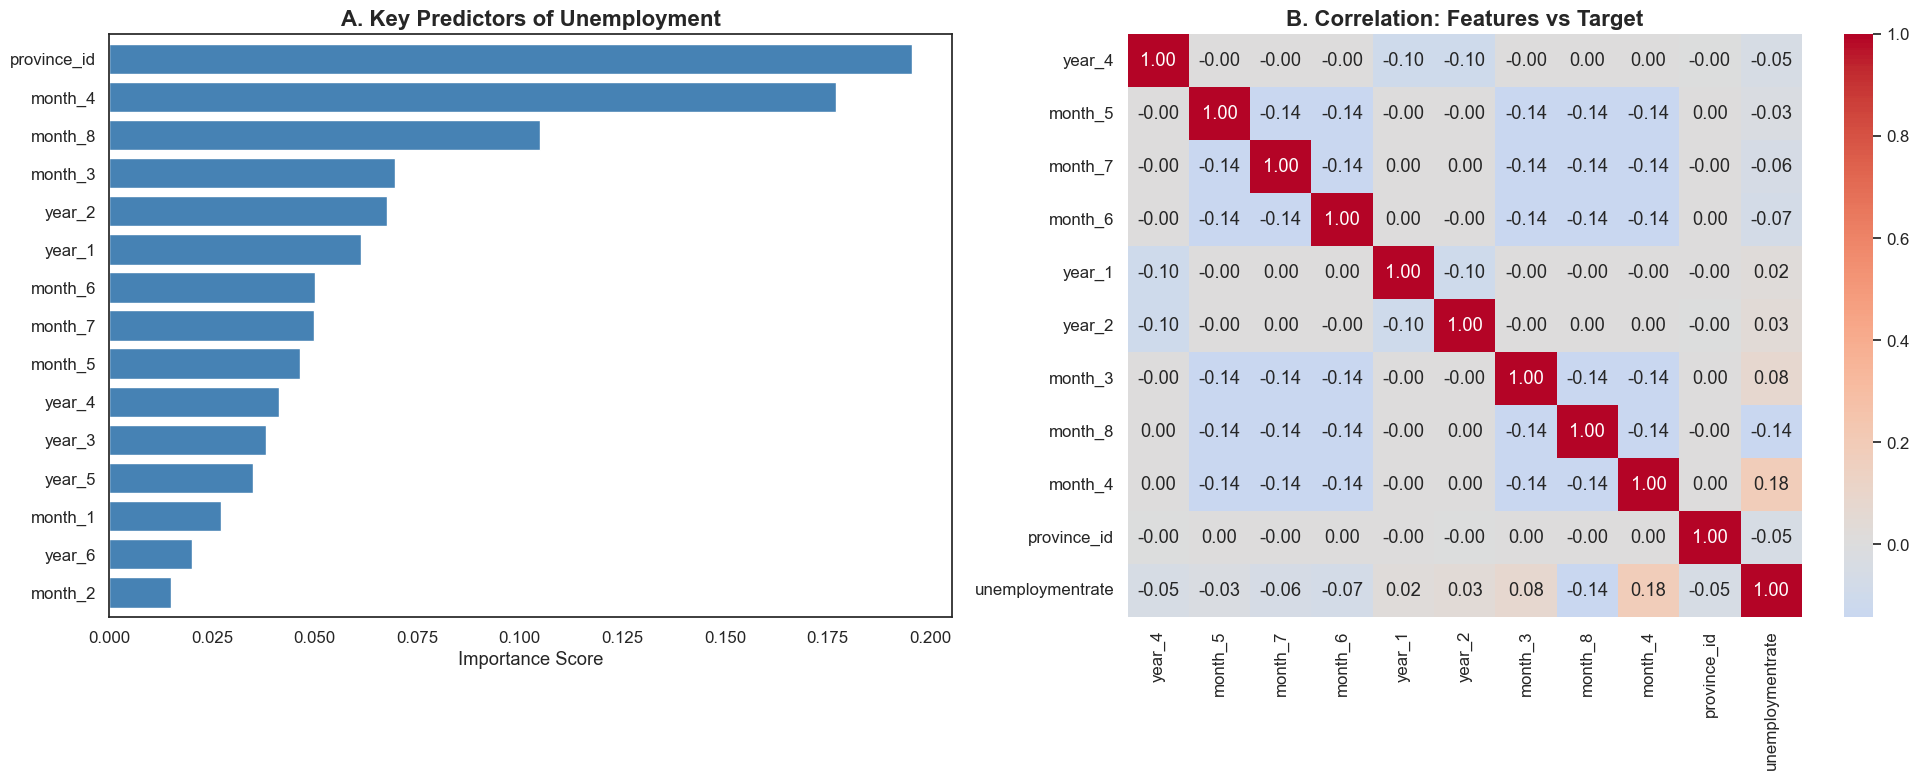

In [5]:
import seaborn as sns
def plot1(model, total_features, data):
    sns.set_theme(style="white", font_scale=1.1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=total_features).sort_values(ascending=True).tail(15)
    feat_imp.plot(kind='barh', color='steelblue', ax=ax1, width=0.8)
    ax1.set_title("A. Key Predictors of Unemployment", fontsize=16, fontweight='bold')
    ax1.set_xlabel("Importance Score")

    top_cols = feat_imp.tail(10).index.tolist() + ['unemploymentrate']  ## 选取前10个特征列 + 目标值列
    plot_corr = data[top_cols].copy()  #创建一个专门用于绘图的副本，防止修改原始数据
    if plot_corr['province_id'].dtype == 'object' or plot_corr['province_id'].dtype.name == 'category':
        plot_corr['province_id'] = pd.factorize(plot_corr['province_id'])[0]
    corr_matrix = plot_corr.corr(numeric_only=True)
    
    
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax2)
    ax2.set_title("B. Correlation: Features vs Target", fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot1(model, total_features, data)

These two figures, through machine learning auditing (Figure A) and correlation analysis (Figure B), establish the reliability of the counterfactual predictions. Figure A (feature importance) shows that province (province_id) is the most crucial variable determining the unemployment rate, with a weight close to 20%, confirming significant spatial heterogeneity in the Canadian labor market. Simultaneously, the model accurately captures two key seasonal nodes: April (end of winter semester) and December (year-end). Figure B (heatmap) further reveals the underlying linear relationships between variables; these low correlation coefficients indicate that the unemployment rate is driven by multiple nonlinear factors, verifying that XGBoost nonlinear modeling is better at capturing complex policy shocks than traditional linear regression.

### b. Predicted vs Actual Unemployment by Region and Group （3✖2 matrix diagrams)

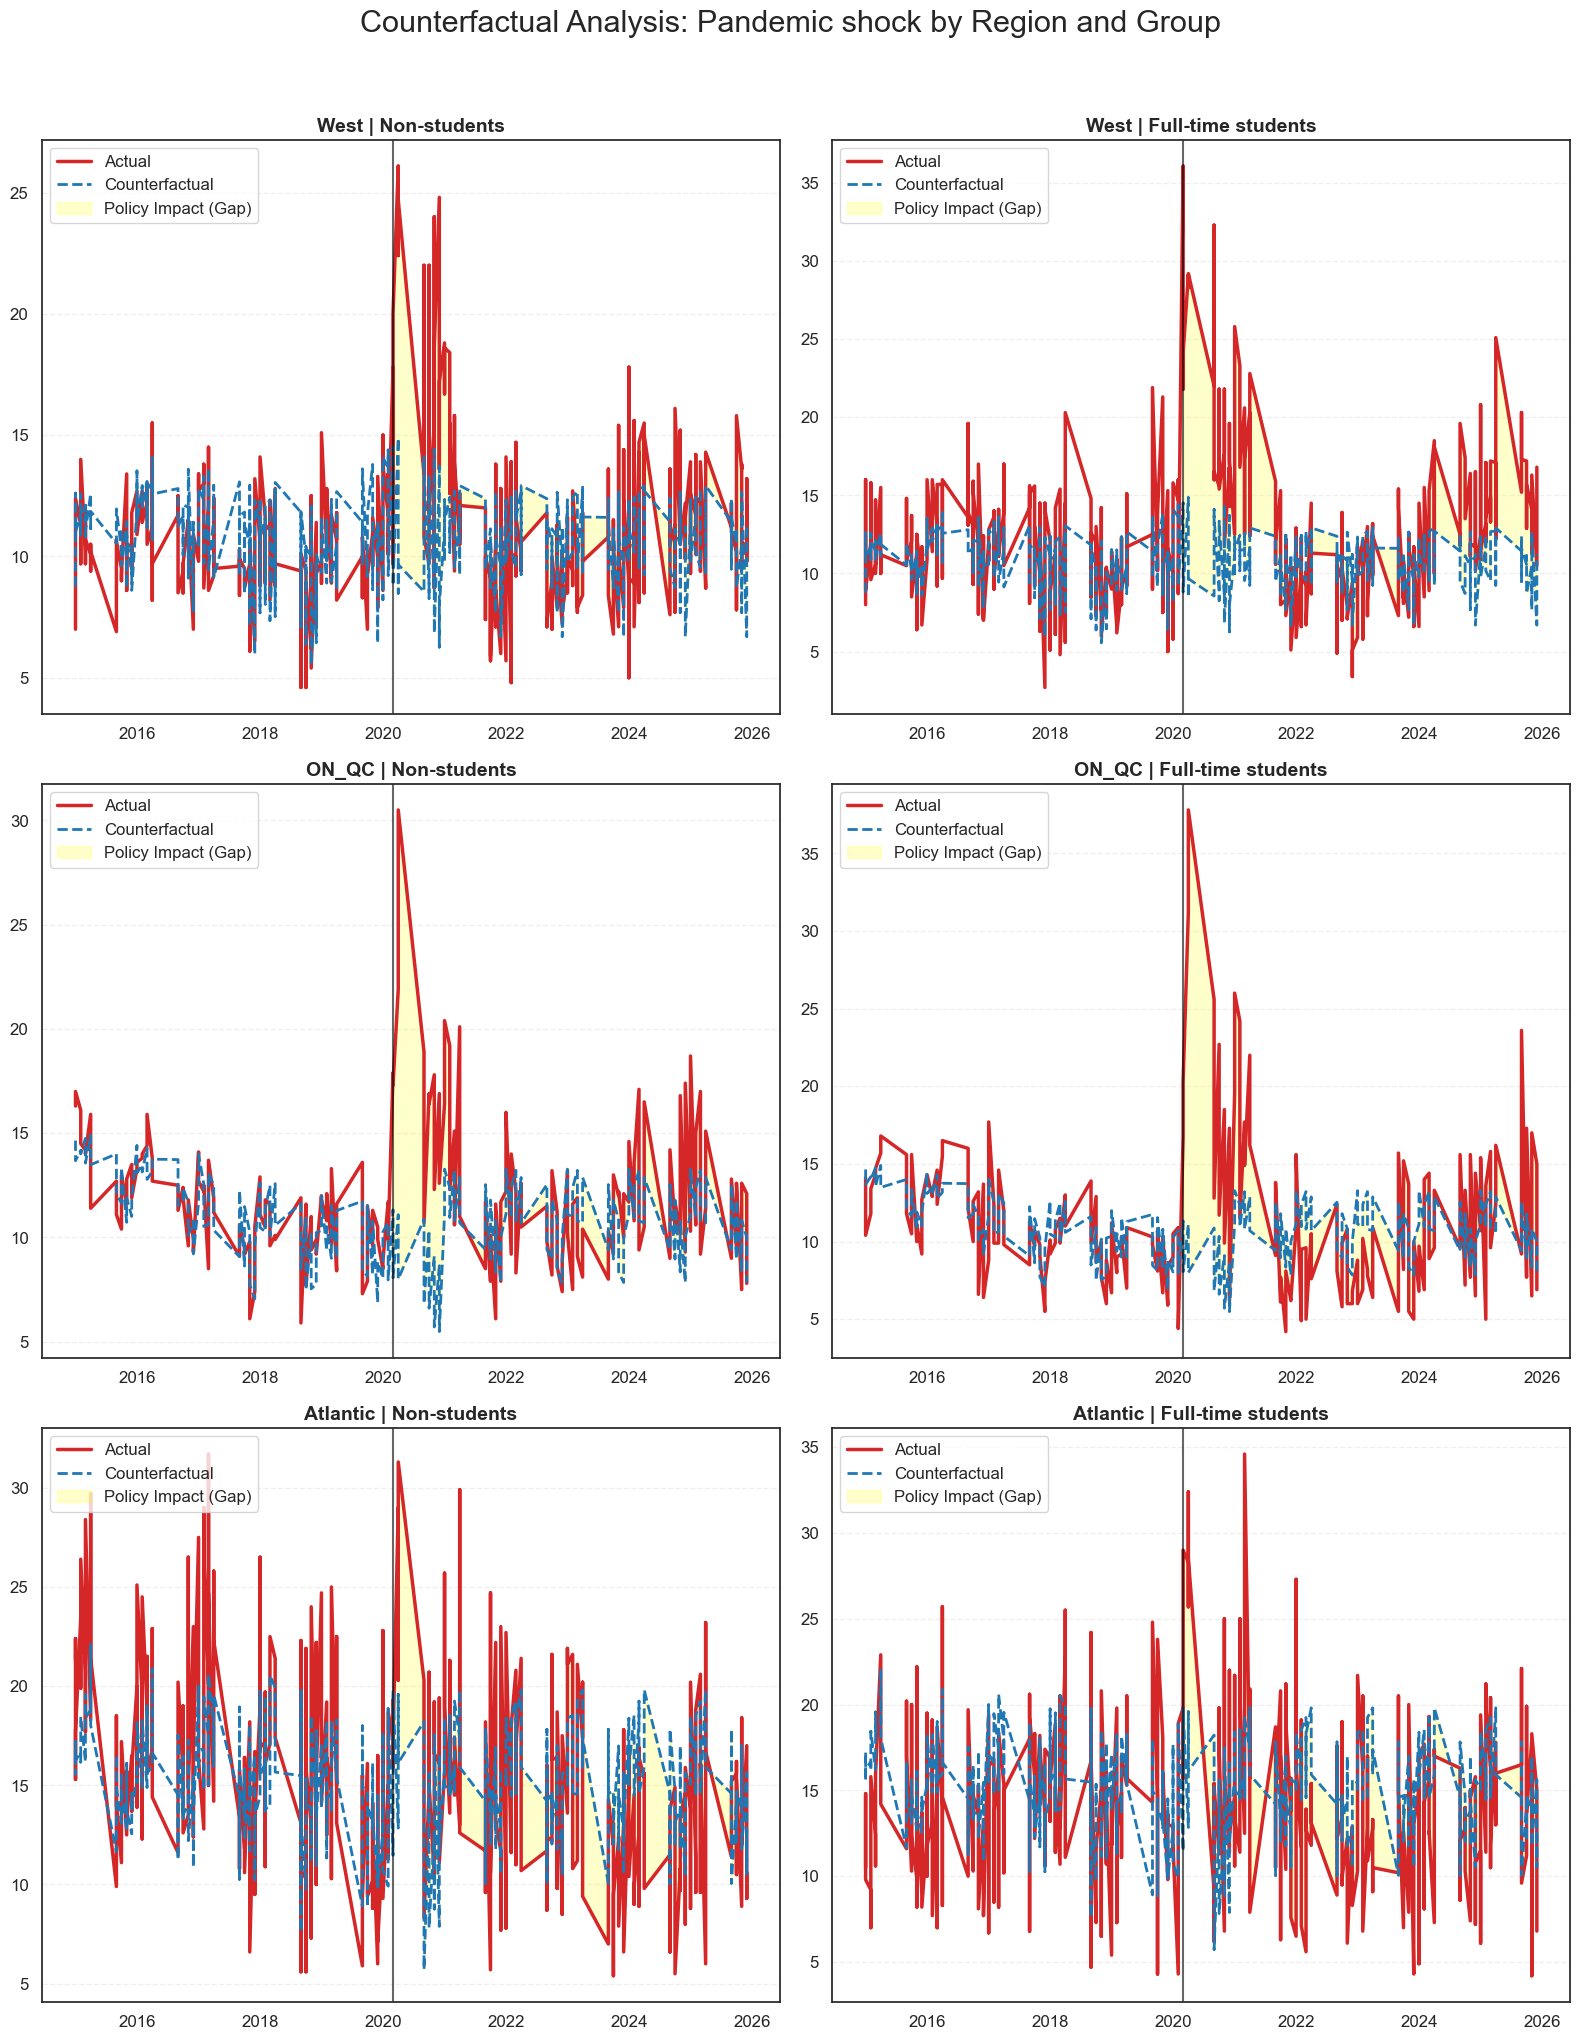

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

X_features = data[total_features].copy()
X_features['province_id'] = X_features['province_id'].astype('category')
data['pred_unem'] = model.predict(X_features)

register_matplotlib_converters()
def plot_3x2_matrix(data):
    # 1. 区域映射
    region_map = {
        'Alberta': 'West', 'British Columbia': 'West', 'Saskatchewan': 'West', 'Manitoba': 'West',
        'Ontario': 'ON_QC', 'Quebec': 'ON_QC',
        'New Brunswick': 'Atlantic', 'Newfoundland and Labrador': 'Atlantic', 
        'Nova Scotia': 'Atlantic', 'Prince Edward Island': 'Atlantic'}
    
    data['region_group'] = data['province_id'].map(region_map)
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    
    regions = ['West', 'ON_QC', 'Atlantic']  #列出三类区域名
    groups = ['Non-students', 'Full-time students']  #列出两类人群
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 20), sharex=False)
    vline_date = pd.to_datetime('2020-03-01')  #规定划分日期 （2020-03为界）
    
    for i, region in enumerate(regions):   #在"regions"跑循环，确保每一种去域名都能轮到
        for j, student_type in enumerate(groups): #在 "groups"中跑循环，确保每一类人群都能轮到
            ax = axes[i, j] # i代表地区，j代表群体
            # 筛选特定区域和群体
            subset = data[(data['region_group'] == region) & (data['students'] == student_type)].sort_values('date')
            
            # 绘制实际值（红色实线）和预测值（蓝色虚线）
            ax.plot(subset['date'], subset['unemploymentrate'], color='#d62728', label='Actual', lw=2.5)
            ax.plot(subset['date'], subset['pred_unem'], color='#1f77b4', linestyle='--', label='Counterfactual', lw=2)
            
            # 填充冲击缺口 (Gap) - 从 2020年3月开始
            covid_period = subset['date'] >= vline_date
            ax.fill_between(subset['date'], subset['unemploymentrate'], subset['pred_unem'], where=covid_period, color='yellow', alpha=0.2, label='Policy Impact (Gap)')
            
            # 加入 2020.03 垂直分界线
            ax.axvline(vline_date, color='black', linestyle='-', alpha=0.6)
            
            # 细节美化
            ax.set_title(f"{region} | {student_type}", fontsize=14, fontweight='bold')
            ax.grid(axis='y', linestyle='--', alpha=0.3)
            ax.legend(loc='upper left')

    plt.suptitle("Counterfactual Analysis: Pandemic shock by Region and Group", fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

# 第三步：正式出图
plot_3x2_matrix(data)

* As the $3 \times 2$ matrix diagrams demonstrate, the actual unemployment rates (red line) in the West and ON_QC deviated sharply from the Counterfactual baseline (blue dashed line) in 2020, reflecting the high sensitivity of these regions' labor markets to macroeconomic shocks. In contrast, the absolute unemployment gap (yellow area) in the Atlantic region was relatively smaller, likely due to the structural resilience of its industries and the stabilizing effect of the 'Atlantic Bubble' policy. A compelling paradox arises when comparing these visualizations with the DID results: while the DID coefficient for full-time students was not statistically significant, the $3 \times 2$ matrix reveals a substantial absolute gap in ON_QC compared to the Atlantic provinces. This discrepancy powerfully demonstrates that for the student labor market, the 'depth' of the shock (the cessation of essential service work) was far more decisive than the 'breadth' of the policy (the strictness of lockdowns). It suggests a 'threshold effect': once essential services were shut down, the relative impact on student populations reached a peak that local policy flexibility could not significantly mitigate, leading to the observed 'resonance' in shock intensity across regions.

### c. Provincial Comparison of Cumulative Unemployment Gaps

In [44]:
vline_date = pd.to_datetime('2020-03-01')
covid_period = data[data['date'] >= vline_date]

map_results = []
for student_type in groups:
    for prov_id in data['province_id']:
        # 筛选单省、单人群的后冲击数据
        subset = covid_period[(covid_period['province_id'] == prov_id) & (covid_period['students'] == student_type)]
        cumulative_gap = (subset['unemploymentrate'] - subset['pred_unem']).sum()
        map_results.append({'Group': student_type, 'Province': prov_id, 'Cumulative_Gap': cumulative_gap})

table = pd.DataFrame(map_results)
table

,Group,Province,Cumulative_Gap
0,Non-students,Alberta,91.066134
1,Non-students,Alberta,91.066134
2,Non-students,Alberta,91.066134
3,Non-students,Alberta,91.066134
4,Non-students,Alberta,91.066134
...,...,...,...
3515,Full-time students,Saskatchewan,41.182244
3516,Full-time students,Saskatchewan,41.182244
3517,Full-time students,Saskatchewan,41.182244
3518,Full-time students,Saskatchewan,41.182244


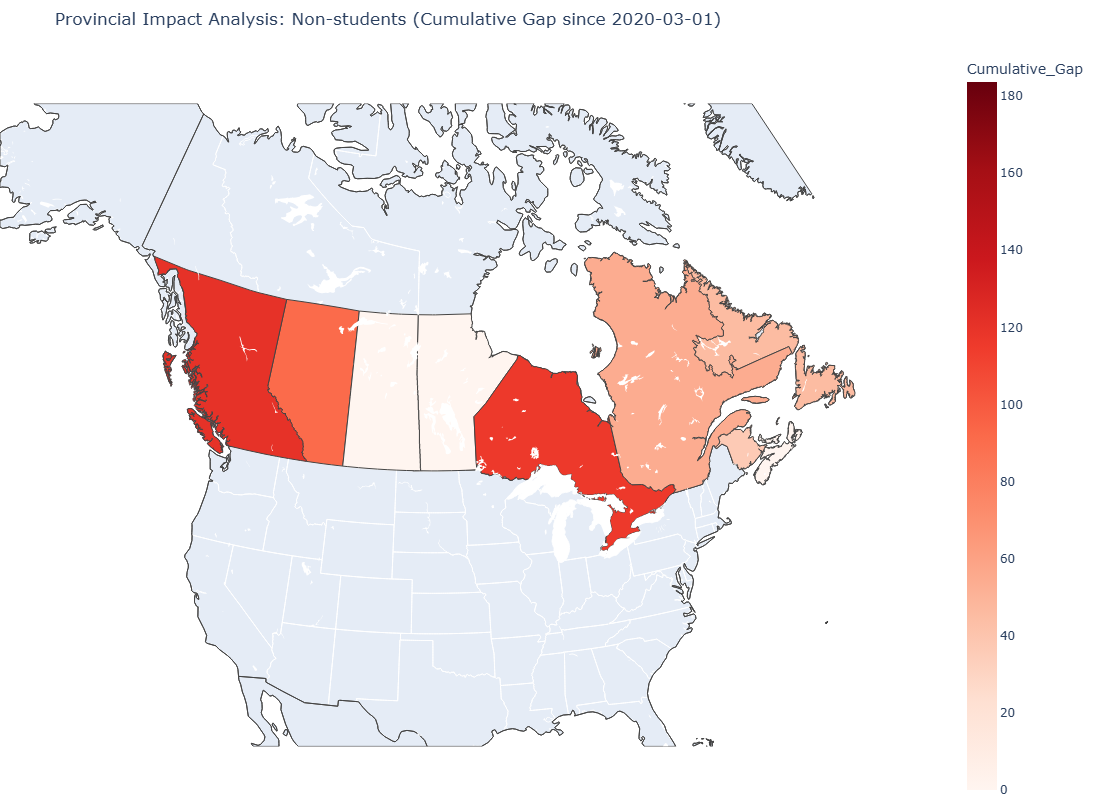

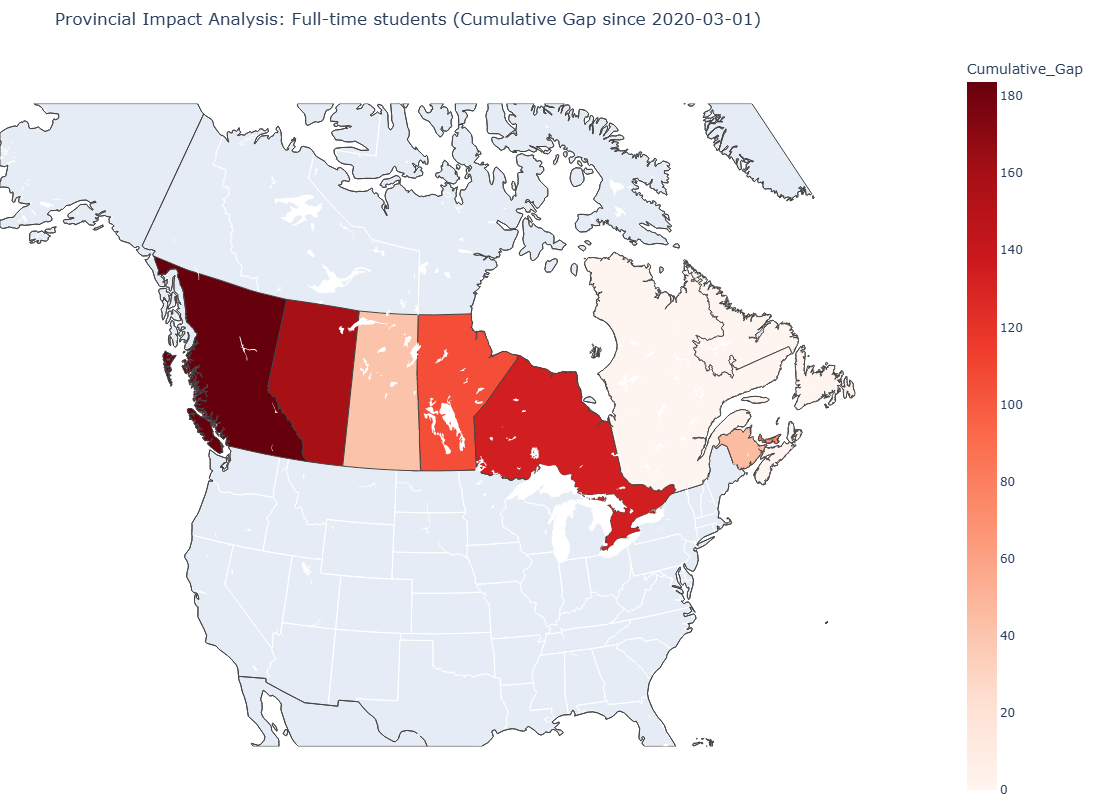

In [45]:
import plotly.express as px

# 加拿大标准 GeoJSON
url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/canada.geojson"

# 统一最大值，确保对比感
global_max = table['Cumulative_Gap'].max()

for group in groups:
    fig = px.choropleth(
        show_map[table['Group'] == group],
        geojson=url,
        locations='Province',
        featureidkey="properties.name",
        color='Cumulative_Gap',
        color_continuous_scale="Reds",
        range_color=[0, global_max], # 锁定量程
        scope="north america",
        hover_data={'Cumulative_Gap': ':.2f', 'Province': True},
        title=f"Provincial Impact Analysis: {group} (Cumulative Gap since {vline_date.date()})")
    
    # 聚焦加拿大
    fig.update_geos(
    visible=True, 
    resolution=50,
    showcountries=True, 
    showcoastlines=True,
    fitbounds="locations") # 如果有的省份没数据，设为 False 可以看到底图轮廓

    fig.update_layout(
    width=1000, 
    height=800,
    margin={"r":0, "t":50, "l":0, "b":0}) # 极致压缩边距

    fig.show()

* The two interactive diagrams show the cumulative gap between actual and conterfactual unemployment for the ten provinces after 2020-03. For the non-students group, the cumulative gap in Ontario is $116.2$ and the period is from 2020-03 to 2025-12 which has 46 months, which means the actual unemployment rate of each month is about $2.526%$ higher on average than the predicted conterfactual rate as the long-term persistent shock by COVID-19. The cumulative gap in Manitoba is $-40.46$, it can be considered as the gradual restore, and even the situation of unemployment has been recoved as better than the period before COVID-19 starts.

* As for full-time students, it is clear that BC has the most serious long-term shock, the cumulative gap is $183.71$, which means the actual unemployment rate of each month is around $4%$ higher on average than the predicted conterfactual rate. In contrast, Quebec and the Atlantic provinces except New Brunswick have different conditions, their cumulative gaps are negative which can be thought their have been recovered gradually. 

# *7.Theoretical Details (Optional)

## (1) Why use Driscoll-Kraay Standard Error?

* Well, according to the tests in stata, I find there are groupwise heteroscedasticity, contemporaneous correlation and groupwise correlation in this long panel data. Cluster robust standar error is reasonable to use only if the error terms within different groups are mutually independent, while obviously it is not reasonable here, because groupwise correlation exists, in other words, the error terms within groups are correlated instead of being mutually independent, so cluster robust standard error is not reasonable in this case here. 

## (2) Why not use pooled OLS Model?

* For using pooled OLS regression, there must be a strong assumption that each individual (in this case, it is province) has no individual heterogeneity, which means the effect brought by individual heterogeneity is none. In reality, this is inappropriate, because each province has its own heterogeneity, such as population, climate, resources, GDP per capital and so on. Therefore, the effect brought by each province's heterogeneity cannot be ignored, if I still use pooled OLS, then their heterogeneity would be omitted which results in heterogeneity bias. 

## (3) Fixed Effects Estimator

### a. Derivation Process

$$Y_{it} = X_{it}'\beta + \mu_i + \varepsilon_{it}\tag{6}$$

$$\frac{1}{T} \sum_{t=1}^{T} Y_{it} = \left( \frac{1}{T} \sum_{t=1}^{T} X_{it}' \right) \beta + u_i + \frac{1}{T} \sum_{t=1}^{T} \varepsilon_{it}\tag{7}$$

$$\overline{Y}_i = \overline{X}_i' \beta + u_i + \overline{\varepsilon}_i\tag{8}$$

$$(Y_{it} - \bar{Y}_i) = (X_{it} - \bar{X}_i)' \beta + (\varepsilon_{it} - \bar{\varepsilon}_i)\tag{9}$$


Where I define$$\widetilde{Y}_{it} = Y_{it} - \bar{Y}_i, \quad \widetilde{X}_{it} = X_{it} - \bar{X}_i, \quad\tilde\varepsilon_{it} = \varepsilon_{it}- \bar{\varepsilon}_i\tag{10}$$

$$\widetilde{Y}_{it} = \widetilde{X}_{it}' \beta + \tilde{\varepsilon}_{it}\tag{11}$$

Conduct OLS regression estimation on equation (11) to obtain the fixed effect estimator as showing as equation (12) below.

$$\hat{\beta}_{fe} = \left( \sum_{i=1}^{N} \sum_{t=1}^{T} \widetilde{X}_{it} \widetilde{X}_{it}' \right)^{-1} \left( \sum_{i=1}^{N} \sum_{t=1}^{T} \widetilde{X}_{it} \widetilde{Y}_{it} \right)\tag{12}$$

### b. Fixed Effects Covariance Matrix Estimation

* In general, there are two situations to calculate the covariance matrix estimation: homoscedasticity and heteroskedasticity. In the real-world problems, homoscedasticity is almost not existent, so in this case, I only consider with the cluster heteroskedasticity robust covariance matrix. 

$$\widehat{V}_{\text{fe}}^{\text{cluster}} = \left( \widetilde{X}' \widetilde{X} \right)^{-1} \left( \sum_{i=1}^N \widetilde{X}_i' \widehat{\varepsilon}_i \widehat{\varepsilon}_i' \widetilde{X}_i \right) \left( \widetilde{X}' \widetilde{X} \right)^{-1}\tag{13}$$

* However, as I said above, this long panel data has groupwise heteroscedasticity, contemporaneous correlation and groupwise correlation, therefore Driscoll-Kraay standard error is more reasonable than cluster robust standard error.

### c. Consistency and Asymptotic Distribution of Fixed Effects Estimator

$$\hat{\beta}_{fe} = \beta + \left( \sum_{i=1}^N \sum_{t=1}^T \widetilde{X}_{it} \widetilde{X}_{it}' \right)^{-1} \left( \sum_{i=1}^N \sum_{t=1}^T \widetilde{X}_{it} \widetilde{\varepsilon}_{it} \right)\tag{14}$$

$$\text{plim}_{N \to \infty} \hat{\beta}_{fe} = \beta + E \left[ \sum_{t=1}^T \widetilde{X}_{it} \widetilde{X}_{it}' \right]^{-1} E \left[ \sum_{t=1}^T \widetilde{X}_{it} \tilde{\varepsilon}_{it} \right]\tag{15}$$

* Equation (15) shows how the fixed effect estimator will convergent to the real parameter by probability in large sample based on Law of Large Numbers(LLN)， where "plim" stands for probability limit. The second item equals zero, because of the strong assumption of orthogonality between independent variables and error term as $$ E \left[ \sum_{t=1}^T \widetilde{X}_{it} \tilde{\varepsilon}_{it} \right ] = 0$$

Thereby, it has been proved that the fixed effect estimator is consistent.

* Now let's look at asymptotic distribution of the fixed effect estimator.

$$\sqrt{N}(\hat{\beta}_{fe} - \beta) \xrightarrow{d} N(0, {V}_{\text{fe}}^{\text{cluster}})\tag{16}$$

$$\widehat{V}_{\text{fe}}^{\text{cluster}} = (\widetilde{X}' \widetilde{X})^{-1} \widehat{\Omega} (\widetilde{X}' \widetilde{X})^{-1}\tag{17}$$

#### Where $\widehat{\Omega}$ can be defined as：
$$\widehat{\Omega} = \sum_{i=1}^{N} \widetilde{X}_i' \widehat{\varepsilon}_i \widehat{\varepsilon}_i' \widetilde{X}_i$$


## (4). Fixed Effects Model and Random Effects Model

* The selection of using fixed effect model or random effect model is actually the trade-off between robustness and efficiency. Fixed effects (FE) completely eliminates the endogeneity bias caused by individual heterogeneity effect's correlation with the independent variable by eliminating $u_i$, thus making it more robust in empirical studies. Even if $u_i$ performs extremely poorly, the coefficients remain consistent. In contrast, random effects (RE) are based on a stronger assumption that $u_i$ is completely unrelated to the independent variable. Although this can be traded for higher statistical efficiency (smaller variance), the results of RE will be biased once this assumption fails in reality.  